In [16]:

import os
import pandas as pd
import numpy as np
import re
import unicodedata
import shutil
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder, LabelBinarizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.utils import shuffle
import eli5
from eli5.sklearn import PermutationImportance
from eli5 import show_weights, show_prediction
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from scikeras.wrappers import KerasClassifier
from transformers import TFAutoModel, AutoTokenizer
from datasets import Dataset
import torch
from gensim.models import Word2Vec
import gensim
print(f"✅ TensorFlow: {tf.__version__}")
print(f"✅ PyTorch: {torch.__version__}")
print(f"✅ Gensim: {gensim.__version__}")


✅ TensorFlow: 2.18.0
✅ PyTorch: 2.9.0+cu128
✅ Gensim: 4.4.0


# CONFIGURAÇÕES

In [17]:
BASE_FOLDER_TRAIN = "treino"
TRAIN_FILE = "ep2-train.csv"
preprocess_params_baseline = {
    "lowercase": True,           
    "normalize_unicode": False,
    "remove_extra_whitespace": True,
    "remove_punct": False,        

    "normalize_email": True,
    "normalize_url": True,
    "normalize_phone": True,
    "normalize_date": True,
    "normalize_time": True,
    "normalize_percent": True,
    "normalize_document": True,
    "normalize_code": True,
    "normalize_law": True,
    "normalize_process_number": True,
}

preprocess_params_mlp = {
    "lowercase": True,            
    "normalize_unicode": False,
    "remove_extra_whitespace": True,
    "remove_punct": False,   
    
    "normalize_email": True,
    "normalize_url": True,
    "normalize_phone": True,
    "normalize_date": True,
    "normalize_time": True,
    "normalize_percent": True,
    "normalize_document": True,
    "normalize_code": True,
    "normalize_law": True,
    "normalize_process_number": True,
}

preprocess_params_bert = {
    "lowercase": False,            
    "normalize_unicode": False,
    "remove_extra_whitespace": True,
    "remove_punct": False,
    "normalize_email": False,
    "normalize_url": False,
    "normalize_phone": False,
    "normalize_date": False,
    "normalize_time": False,
    "normalize_percent": False,
    "normalize_document": False,
    "normalize_code": False,
    "normalize_law": False,
    "normalize_process_number": False,
}

In [ ]:
# Configuração do Baseline (parâmetros fixos)
BASELINE_CONFIG = {
    'vectorizer': {
        'max_features': 20000,
        'ngram_range': (2, 2)
    },
    'model': {
        'C': 1.0,
        'solver': 'lbfgs',
        'class_weight': 'balanced',
        'max_iter': 1000,
        'random_state': 1
    }
}


# ANÁLISE DE BALANCEAMENTO DOS DATASETS


In [19]:
def analisar_balanceamento(file_name):
    path = os.path.join(BASE_FOLDER_TRAIN, file_name)
    df = pd.read_csv(path, sep=";", encoding="latin1")
    # Informações básicas
    print(f"\nINFORMAÇÕES GERAIS:")
    print(f"Total de linhas: {len(df):,}")
    print(f"Total de colunas: {len(df.columns)}")
    print(f"Colunas: {list(df.columns)}")
    
    print(f"\nVALORES NULOS:")
    print(f"Coluna 'req_text': {df['req_text'].isna().sum()}")
    print(f"Coluna 'profession': {df['profession'].isna().sum()}")
    
    # Distribuição das classes
    print(f"DISTRIBUIÇÃO DAS CLASSES:")
    contagem_classes = df['profession'].value_counts()
    print(contagem_classes)
    
    print(f"PORCENTAGEM POR CLASSE:")
    porcentagem_classes = df['profession'].value_counts(normalize=True) * 100
    for classe, perc in porcentagem_classes.items():
        count = contagem_classes[classe]
        print(f"   • {classe}: {count:,} ({perc:.2f}%)")
    return df, contagem_classes


In [20]:
resultados_analise = {}

df, contagem = analisar_balanceamento(TRAIN_FILE)
resultados_analise[TRAIN_FILE] = {
    'dataframe': df,
    'contagem_classes': contagem
}



INFORMAÇÕES GERAIS:
Total de linhas: 43,678
Total de colunas: 2
Colunas: ['req_text', 'profession']

VALORES NULOS:
Coluna 'req_text': 0
Coluna 'profession': 0
DISTRIBUIÇÃO DAS CLASSES:
profession
government    18782
academic      14593
private       10303
Name: count, dtype: int64
PORCENTAGEM POR CLASSE:
   • government: 18,782 (43.00%)
   • academic: 14,593 (33.41%)
   • private: 10,303 (23.59%)


# PRÉ-PROCESSAMENTO

In [21]:
def normalize_entities(text, params):

    if not isinstance(text, str):
        return ""

    if params.get("normalize_process_number", False):
        # Formato comum de número de processo: 0001234-56.2018.8.09.0001
        text = re.sub(
            r'\b\d{7}-\d{2}\.\d{4}\.\d\.\d{2}\.\d{4}\b',
            '<PROCESS_NUMBER>',
            text
        )
        # Formato alternativo com pontos e barras: 15414.001854/2015-11
        text = re.sub(
            r'\b\d{5}\.\d{6}/\d{4}-\d{2}\b',
            '<PROCESS_NUMBER>',
            text
        )

        # para 48500.004271/2012
        text = re.sub(
            r'\b\d{5}\.\d{6}/\d{4}\b',
            '<PROCESS_NUMBER>',
            text
        )

        #para 850.062/2015
        text = re.sub(
            r'\b\d{3}\.\d{3}/\d{4}\b',
            '<PROCESS_NUMBER>',
            text
        )

        # 850250/2003
        text = re.sub(
            r'\b\d{6}/\d{4}\b',
            '<PROCESS_NUMBER>',
            text
        )


    # 1. EMAIL - Captura endereços de email
    if params.get("normalize_email", False):
        text = re.sub(
            r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b',
            '<EMAIL>',
            text
        )
    
    # 2. URL - Links HTTP/HTTPS e www (MUITO MAIS ROBUSTO)
    if params.get("normalize_url", False):
        # URLs com protocolo (http, https, ftp) - SEM \b para evitar problemas
        # Captura até encontrar espaço, aspas, ou pontuação de fim de frase
        text = re.sub(
            r'(?:https?|ftp)://[^\s\)"<>]+',
            '<URL>',
            text,
            flags=re.IGNORECASE
        )
        # URLs começando com www (incluindo www2, www3, etc)
        text = re.sub(
            r'www\d*\.[^\s\)"<>]+',
            '<URL>',
            text,
            flags=re.IGNORECASE
        )
        # Domínios com caminho explícito
        text = re.sub(
            r'[a-z0-9][-a-z0-9]*\.[a-z]{2,}(?:\.[a-z]{2,})?/[^\s\)"<>]+',
            '<URL>',
            text,
            flags=re.IGNORECASE
        )
    
    # 3. PHONE - Telefones brasileiros
    if params.get("normalize_phone", False):
        # Formato: (85) 9 8645.1524, (85) 98645-1524, 85 98645-1524, etc
        text = re.sub(
            r'\(?\d{2}\)?\s?\d{4,5}[-.\s]?\d{4}',
            '<PHONE>',
            text
        )
    
    # 4. DATE - Várias formatações de data
    if params.get("normalize_date", False):
        # DD/MM/YYYY, DD-MM-YYYY, DD.MM.YYYY
        text = re.sub(
            r'\b\d{1,2}[/.-]\d{1,2}[/.-]\d{2,4}\b',
            '<DATE>',
            text
        )
        # YYYY/MM/DD, YYYY-MM-DD
        text = re.sub(
            r'\b\d{4}[/.-]\d{1,2}[/.-]\d{1,2}\b',
            '<DATE>',
            text
        )
    
    # 5. TIME - Horários (CORRIGIDO)
    if params.get("normalize_time", False):
        # Formato HH:MM ou HH:MM:SS
        text = re.sub(
            r'\b\d{1,2}:\d{2}(?::\d{2})?\b',
            '<TIME>',
            text
        )
        # Formato HHhMM (ex: 14h30)
        text = re.sub(
            r'\b\d{1,2}h\d{2}\b',
            '<TIME>',
            text
        )
    
    # 6. PERCENT - Porcentagens
    if params.get("normalize_percent", False):
        text = re.sub(
            r'\b\d+(?:[.,]\d+)?%',
            '<PERCENT>',
            text
        )
    
    # 7. DOCUMENT - CPF e CNPJ
    if params.get("normalize_document", False):
        # CPF: 123.456.789-00
        text = re.sub(
            r'\b\d{3}\.\d{3}\.\d{3}-\d{2}\b',
            '<DOCUMENT>',
            text
        )
        # CNPJ: 12.345.678/0001-00
        text = re.sub(
            r'\b\d{2}\.\d{3}\.\d{3}/\d{4}-\d{2}\b',
            '<DOCUMENT>',
            text
        )
    
    # 8. CODE - Códigos de rastreamento e processos
    if params.get("normalize_code", False):
        # Códigos de rastreamento (ex: RU101805325NL, PG326875631BR)
        text = re.sub(
            r'\b[A-Z]{2}\d{9,}[A-Z]{2}\b',
            '<CODE>',
            text
        )
        # Códigos de processo (ex: AC-2000-08012-000640, DAE 07.16.17365.94815-1)
        text = re.sub(
            r'\b[A-Z]{2,}-?\d{4}-\d{5}-\d{5,6}(?:-\d)?\b',
            '<CODE>',
            text
        )
        # DAE com pontos
        text = re.sub(
            r'\b\d{2}\.\d{2}\.\d{5}\.\d{5}-\d\b',
            '<CODE>',
            text
        )
    
    # 9. LAW - Referências legais
    if params.get("normalize_law", False):
        text = re.sub(
            r'\bn[ºo°]?\s*\d+(?:/\d{4})?\b',
            '<LAW>',
            text,
            flags=re.IGNORECASE
        )
    
    return text


In [ ]:
def preprocess_operations(text, params):

    # Validação de entrada
    if not isinstance(text, str):
        return ""
    
    if len(text.strip()) == 0:
        return ""
    
    #Normalização de entidades (
    text = normalize_entities(text, params)
    
    #Normalização Unicode
    if params.get("normalize_unicode", False):
        text = unicodedata.normalize("NFKC", text)
    
    #Lowercase
    if params.get("lowercase", False):
        text = text.lower()
    
    #Remover pontuação (mas preservar tokens especiais <...>)
    if params.get("remove_punct", False):
        # Proteger tokens especiais temporariamente (padrão melhorado)
        text = re.sub(r'<(\w+)>', r'__TOKEN__\1__TOKEN__', text)
        # Remover pontuação (mas manter espaços e alfanuméricos)
        text = re.sub(r"[^\w\s]", " ", text)
        # Restaurar tokens especiais
        text = re.sub(r'__TOKEN__(\w+)__TOKEN__', r'<\1>', text)
    
    #Remover espaços extras
    if params.get("remove_extra_whitespace", False):
        # Remover múltiplos espaços
        text = re.sub(r"\s+", " ", text)
        # Remover espaços no início e fim
        text = text.strip()
    
    #Validação final
    if len(text.strip()) == 0:
        return ""
    
    return text

def preprocess_data(path, output_path, params):
    col_text, col_label = "req_text", "profession"
    
    print("PRÉ-PROCESSAMENTO DE DADOS")
    
    if not os.path.exists(path):
        print(f"{path} não encontrado.")
        return None
    df = pd.read_csv(path, sep=";", encoding="latin1")    
    if col_text not in df.columns or col_label not in df.columns:
        return None
    
    #Limpeza inicial
    initial_count = len(df)
    
    #Aplicar pré-processamento
    print(f"\n⚙️  Aplicando pré-processamento...")
    print(f"   • Parâmetros ativos:")
    active_params = [k for k, v in params.items() if v]
    if active_params:
        for param in active_params:
            print(f"     - {param}")
    else:
        print(f"     (nenhum parâmetro de pré-processamento ativo)")
    
    processed_texts = []
    errors = 0
    
    for idx, text in enumerate(df[col_text]):
        try:
            processed = preprocess_operations(str(text), params)
            processed_texts.append(processed)
        except Exception as e:
            # Em caso de erro, usar texto vazio
            processed_texts.append("")
            errors += 1
        if len(df) > 10 and (idx + 1) % (len(df) // 10) == 0:
            progress = ((idx + 1) / len(df)) * 100
            print(f"   • Progresso: {progress:.0f}%")
    
    if errors > 0:
        print(f"Total de erros durante processamento: {errors}")
    
    df['req_text'] = processed_texts
    

    df_processed = df[['req_text', col_label]].copy()

    df_processed.to_csv(output_path, sep=";", encoding="utf-8", index=False)
    print(f"Arquivo salvo: {output_path}")
    
    df_processed = shuffle(df_processed, random_state=1).reset_index(drop=True)
    le = LabelEncoder()
    y = le.fit_transform(df_processed[col_label])
    
    label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))    
    class_dist = pd.Series(y).value_counts().sort_index()
    for class_idx, class_name in enumerate(le.classes_):
        count = class_dist[class_idx]
        percentage = (count / len(y)) * 100
        print(f"     - {class_name}: {count:,} ({percentage:.2f}%)")
    
    X = df_processed['req_text'].values
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.15, stratify=y, random_state=1
    )
    
    print(f"\nDados preparados para treinamento!")
    print(f"Treino: {len(X_train):,} textos")
    print(f"Teste: {len(X_test):,} textos")
    print(f"Proporção treino/teste: {len(X_train)/len(X_test):.2f}:1")
    
    # Estatísticas finais
    print(f"\n📊 Estatísticas finais:")
    print(f"Total de textos processados: {len(df_processed):,}")
    print(f"Total de classes: {len(le.classes_)}")
    print(f"Tamanho do conjunto de treino: {len(X_train):,}")
    print(f"Tamanho do conjunto de teste: {len(X_test):,}")
    
    return X_train, X_test, y_train, y_test, le

In [23]:
input_file = os.path.join(BASE_FOLDER_TRAIN, TRAIN_FILE)


output_file_baseline = os.path.join(BASE_FOLDER_TRAIN, "ep2-train-preprocessed-baseline.csv")
print("PRÉ-PROCESSAMENTO 1: REGRESSÃO LOGÍSTICA (BASELINE)")
print(f"Arquivo de entrada: {input_file}")
print(f"Arquivo de saída: {output_file_baseline}")

result_baseline = preprocess_data(input_file, output_file_baseline, preprocess_params_baseline)

if result_baseline is not None:
    X_train_baseline, X_test_baseline, y_train_baseline, y_test_baseline, label_encoder_baseline = result_baseline
    print(f"\nPRÉ-PROCESSAMENTO BASELINE CONCLUÍDO!")
else:
    print(f"\nERRO NO PRÉ-PROCESSAMENTO BASELINE")
    X_train_baseline, X_test_baseline, y_train_baseline, y_test_baseline, label_encoder_baseline = None, None, None, None, None


output_file_mlp = os.path.join(BASE_FOLDER_TRAIN, "ep2-train-preprocessed-mlp.csv")

print("PRÉ-PROCESSAMENTO 2: MLP (TF-IDF/Word2Vec)")
print(f"Arquivo de entrada: {input_file}")
print(f"Arquivo de saída: {output_file_mlp}")

result_mlp = preprocess_data(input_file, output_file_mlp, preprocess_params_mlp)

if result_mlp is not None:
    X_train_mlp, X_test_mlp, y_train_mlp, y_test_mlp, label_encoder_mlp = result_mlp
    print(f"\nPRÉ-PROCESSAMENTO MLP CONCLUÍDO!")
else:
    print(f"\nERRO NO PRÉ-PROCESSAMENTO MLP")
    X_train_mlp, X_test_mlp, y_train_mlp, y_test_mlp, label_encoder_mlp = None, None, None, None, None

output_file_bert = os.path.join(BASE_FOLDER_TRAIN, "ep2-train-preprocessed-bert.csv")

print("PRÉ-PROCESSAMENTO 3: BERT")
print(f"Arquivo de entrada: {input_file}")
print(f"Arquivo de saída: {output_file_bert}")

result_bert = preprocess_data(input_file, output_file_bert, preprocess_params_bert)

if result_bert is not None:
    X_train_bert, X_test_bert, y_train_bert, y_test_bert, label_encoder_bert = result_bert
    print(f"\nPRÉ-PROCESSAMENTO BERT CONCLUÍDO!")
else:
    print(f"\nERRO NO PRÉ-PROCESSAMENTO BERT")
    X_train_bert, X_test_bert, y_train_bert, y_test_bert, label_encoder_bert = None, None, None, None, None

# Dataset para Baseline (Regressão Logística)
dataset_baseline = {
    "X_train": X_train_baseline,
    "X_test": X_test_baseline,
    "y_train": y_train_baseline,
    "y_test": y_test_baseline,
    "label_encoder": label_encoder_baseline
}

# Dataset para MLP
dataset_mlp = {
    "X_train": X_train_mlp,
    "X_test": X_test_mlp,
    "y_train": y_train_mlp,
    "y_test": y_test_mlp,
    "label_encoder": label_encoder_mlp
}

# Dataset para BERT
dataset_bert = {
    "X_train": X_train_bert,
    "X_test": X_test_bert,
    "y_train": y_train_bert,
    "y_test": y_test_bert,
    "label_encoder": label_encoder_bert
}

print(f"\nResumo:")
if X_train_baseline is not None:
    print(f"Dataset Baseline: {len(X_train_baseline):,} textos de treino")
if X_train_mlp is not None:
    print(f"Dataset MLP: {len(X_train_mlp):,} textos de treino")
if X_train_bert is not None:
    print(f"Dataset BERT: {len(X_train_bert):,} textos de treino")

PRÉ-PROCESSAMENTO 1: REGRESSÃO LOGÍSTICA (BASELINE)
Arquivo de entrada: treino/ep2-train.csv
Arquivo de saída: treino/ep2-train-preprocessed-baseline.csv
PRÉ-PROCESSAMENTO DE DADOS

⚙️  Aplicando pré-processamento...
   • Parâmetros ativos:
     - lowercase
     - remove_extra_whitespace
     - normalize_email
     - normalize_url
     - normalize_phone
     - normalize_date
     - normalize_time
     - normalize_percent
     - normalize_document
     - normalize_code
     - normalize_law
     - normalize_process_number
   • Progresso: 10%
   • Progresso: 20%
   • Progresso: 30%
   • Progresso: 40%
   • Progresso: 50%
   • Progresso: 60%
   • Progresso: 70%
   • Progresso: 80%
   • Progresso: 90%
   • Progresso: 100%
Arquivo salvo: treino/ep2-train-preprocessed-baseline.csv
     - academic: 14,593 (33.41%)
     - government: 18,782 (43.00%)
     - private: 10,303 (23.59%)

Dados preparados para treinamento!
Treino: 37,126 textos
Teste: 6,552 textos
Proporção treino/teste: 5.67:1

📊 Est

# TREINAMENTO
Classificação de textos entre autores **acadêmicos**, **privados** e **governamentais**

## BASELINE
TF-IDF + Regressão Logística, com análise de features

In [24]:

X_train = dataset_baseline["X_train"]
X_test = dataset_baseline["X_test"]
y_train = dataset_baseline["y_train"]
y_test = dataset_baseline["y_test"]
label_encoder = dataset_baseline["label_encoder"]

print("BASELINE: TF-IDF + REGRESSÃO LOGÍSTICA")
baseline_pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer(
        max_features=BASELINE_CONFIG['vectorizer']['max_features'],
        ngram_range=BASELINE_CONFIG['vectorizer']['ngram_range']
    )),
    ('model', LogisticRegression(
        C=BASELINE_CONFIG['model']['C'],
        solver=BASELINE_CONFIG['model']['solver'],
        class_weight=BASELINE_CONFIG['model']['class_weight'],
        max_iter=BASELINE_CONFIG['model']['max_iter'],
        random_state=BASELINE_CONFIG['model']['random_state']
    ))
])

print(f"\nParâmetros do Baseline:")
print(f"TF-IDF: max_features={BASELINE_CONFIG['vectorizer']['max_features']}, "
      f"ngram_range={BASELINE_CONFIG['vectorizer']['ngram_range']}")
print(f"Logistic Regression: C={BASELINE_CONFIG['model']['C']}, "
      f"solver={BASELINE_CONFIG['model']['solver']}, "
      f"class_weight={BASELINE_CONFIG['model']['class_weight']}")

print(f"\nTreinando modelo")
baseline_pipeline.fit(X_train, y_train)
print(f"Treinamento concluído")
print("VALIDAÇÃO CRUZADA - 10 FOLDS")

print(f"Executando validação cruzada de 10 folds no conjunto de treino...")
cv_scores = cross_val_score(
    baseline_pipeline,
    X_train,
    y_train,
    cv=10,
    scoring='accuracy',
    n_jobs=-1
)

print(f"\nValidação cruzada concluída!")
print(f"\nResultados da Validação Cruzada (10 folds):")
print(f"Acurácia média: {cv_scores.mean():.4f}")
print(f"Acurácia mínima: {cv_scores.min():.4f}")
print(f"Acurácia máxima: {cv_scores.max():.4f}")
print(f"\nAcurácias por fold:")
for fold_idx, score in enumerate(cv_scores, 1):
    print(f"-Fold {fold_idx}: {score:.4f}")


print("TESTE FINAL - 15% SEPARADOS")
baseline_test_score = baseline_pipeline.score(X_test, y_test)
baseline_y_pred = baseline_pipeline.predict(X_test)

print(f"Resultados do Teste Final:")
print(f"Acurácia no conjunto de teste: {baseline_test_score:.4f}")
print(f"Total de amostras de teste: {len(y_test):,}")

#Acurácia no conjunto de treino
baseline_train_score = baseline_pipeline.score(X_train, y_train)

print(f"\nRESULTADOS - BASELINE")
print(f"Train Accuracy: {baseline_train_score:.4f}")
print(f"CV Accuracy (10 folds): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Test Accuracy:  {baseline_test_score:.4f}")

baseline_results = {
    'model_name': 'TF-IDF + Logistic Regression',
    'config': BASELINE_CONFIG,
    'train_score': baseline_train_score,
    'cv_scores': cv_scores,
    'cv_mean': cv_scores.mean(),
    'cv_std': cv_scores.std(),
    'test_score': baseline_test_score,
    'model': baseline_pipeline,
    'vectorizer': baseline_pipeline.named_steps['vectorizer'],
    'classifier': baseline_pipeline.named_steps['model'],
    'predictions': baseline_y_pred
}


BASELINE: TF-IDF + REGRESSÃO LOGÍSTICA

Parâmetros do Baseline:
TF-IDF: max_features=20000, ngram_range=(2, 2)
Logistic Regression: C=1.0, solver=lbfgs, class_weight=balanced

Treinando modelo
Treinamento concluído
VALIDAÇÃO CRUZADA - 10 FOLDS
Executando validação cruzada de 10 folds no conjunto de treino...

Validação cruzada concluída!

Resultados da Validação Cruzada (10 folds):
Acurácia média: 0.6553
Acurácia mínima: 0.6487
Acurácia máxima: 0.6659

Acurácias por fold:
-Fold 1: 0.6539
-Fold 2: 0.6553
-Fold 3: 0.6493
-Fold 4: 0.6523
-Fold 5: 0.6563
-Fold 6: 0.6558
-Fold 7: 0.6659
-Fold 8: 0.6522
-Fold 9: 0.6487
-Fold 10: 0.6630
TESTE FINAL - 15% SEPARADOS
Resultados do Teste Final:
Acurácia no conjunto de teste: 0.6644
Total de amostras de teste: 6,552

RESULTADOS - BASELINE
Train Accuracy: 0.7980
CV Accuracy (10 folds): 0.6553 ± 0.0052
Test Accuracy:  0.6644


### Análise de features do baseline

ANÁLISE DE FEATURES
TOP 10 FEATURES QUE FAVORECEM CADA CLASSE
CLASSE: ACADEMIC

Top 10 Features que favorecem academic:
           feature   weight
        ouvidor do 2.796331
     sou estudante 2.689613
      estudante de 2.386555
    para professor 2.246632
        sr ouvidor 2.232817
 excelentíssimo sr 2.176491
      de professor 2.160889
      de solicitar 2.072162
pesquisa acadêmica 2.010758
        dr ouvidor 1.957839
Figura salva: figuras/top10_features_academic.png


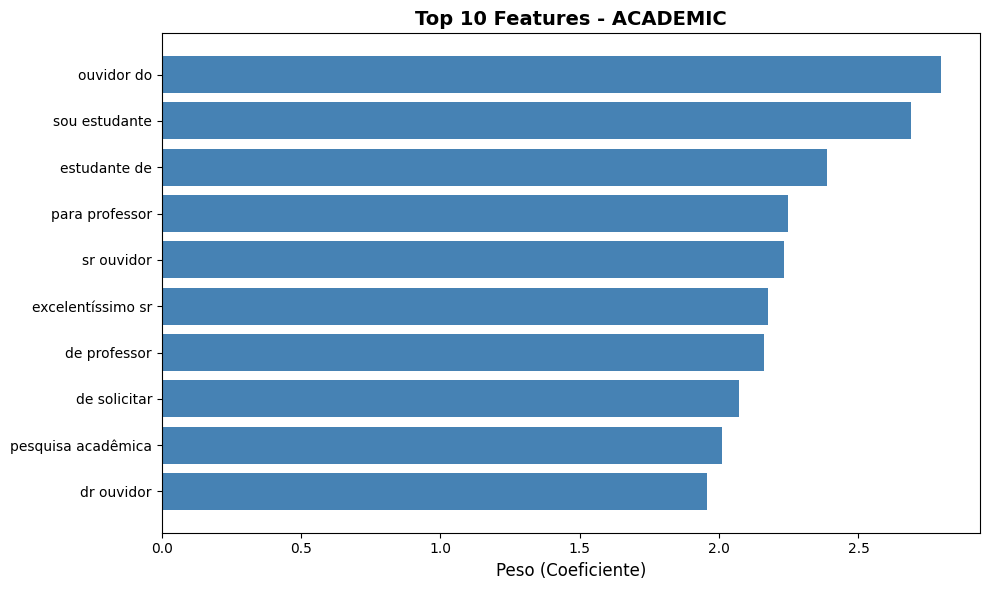

CLASSE: GOVERNMENT

Top 10 Features que favorecem government:
          feature   weight
     sou servidor 2.915100
solicito informar 2.707868
    sou servidora 2.571938
      de mestrado 2.235069
de redistribuição 2.233873
  sua instituição 2.146606
        de gestão 2.116192
  caso afirmativo 1.976000
         no órgão 1.945529
assistente social 1.870296
Figura salva: figuras/top10_features_government.png


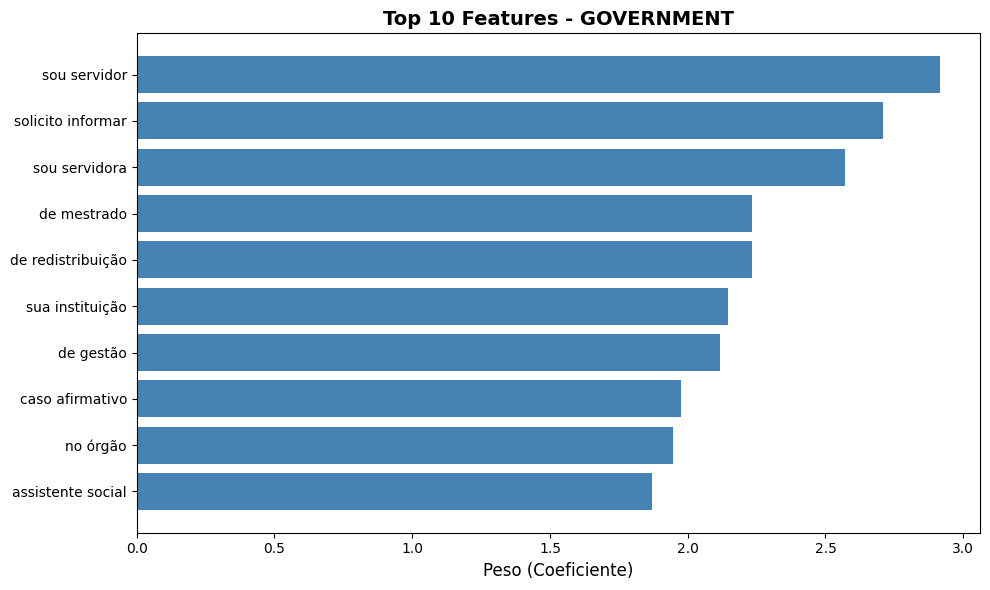

CLASSE: PRIVATE

Top 10 Features que favorecem private:
                   feature   weight
instituição atenciosamente 2.000353
               uma empresa 1.811694
              não sigilosa 1.762146
            processo susep 1.696801
               de empresas 1.648778
                vagos esta 1.623598
              prezados boa 1.613679
               dispõe para 1.597693
             minha empresa 1.590416
                no aguardo 1.571624
Figura salva: figuras/top10_features_private.png


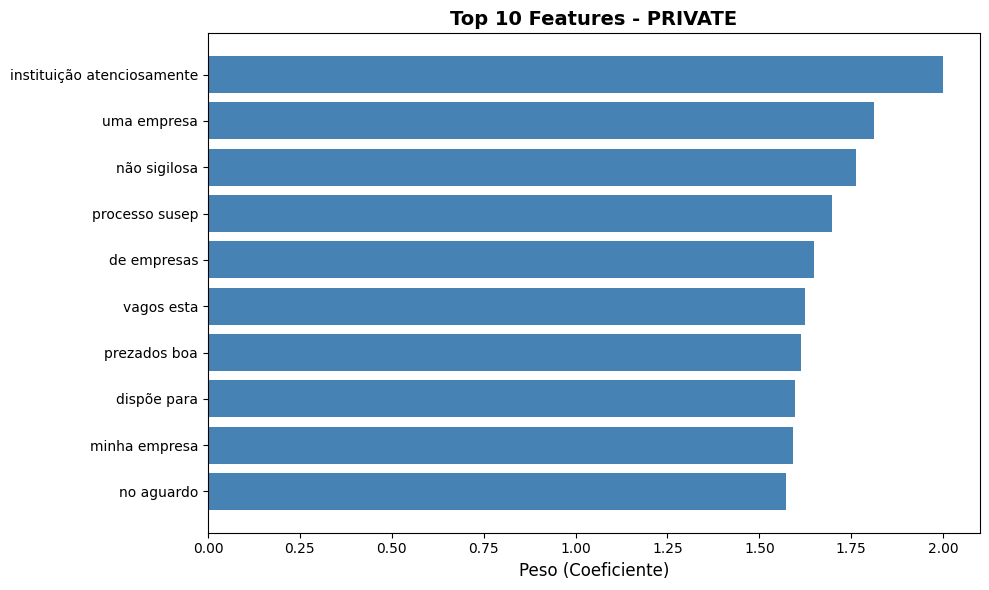

MATRIZ DE CONFUSÃO
Figura salva: figuras/confusion_matrix_baseline.png


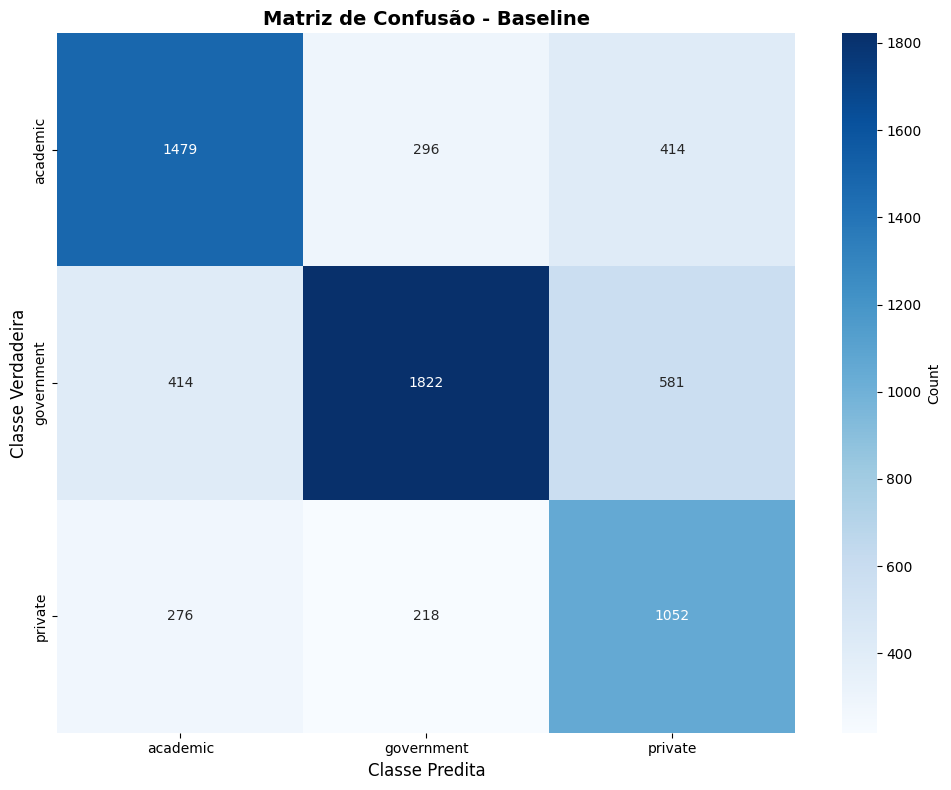


Matriz de Confusão:
            academic  government  private
academic        1479         296      414
government       414        1822      581
private          276         218     1052


In [25]:

print("ANÁLISE DE FEATURES")


feature_names = baseline_results['vectorizer'].get_feature_names_out()
figures_dir = "figuras"
os.makedirs(figures_dir, exist_ok=True)
print("TOP 10 FEATURES QUE FAVORECEM CADA CLASSE")

baseline_feature_analysis = {}

for class_idx, class_name in enumerate(label_encoder.classes_):
    print(f"CLASSE: {class_name.upper()}")
    coef = baseline_results['classifier'].coef_[class_idx]
    
    features_df = pd.DataFrame({
        'feature': feature_names,
        'weight': coef
    })
    positive_features = features_df[features_df['weight'] > 0].copy()
    top_10 = positive_features.nlargest(10, 'weight')
    baseline_feature_analysis[class_name] = {
        'top_10_positive': top_10
    }
    print(f"\nTop 10 Features que favorecem {class_name}:")
    print(top_10[['feature', 'weight']].to_string(index=False))
    plt.figure(figsize=(10, 6))
    plt.barh(range(len(top_10)), top_10['weight'].values, color='steelblue')
    plt.yticks(range(len(top_10)), top_10['feature'].values, fontsize=10)
    plt.xlabel('Peso (Coeficiente)', fontsize=12)
    plt.title(f'Top 10 Features - {class_name.upper()}', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    figure_path = os.path.join(figures_dir, f'top10_features_{class_name}.png')
    plt.savefig(figure_path, dpi=300, bbox_inches='tight')
    print(f"Figura salva: {figure_path}")
    plt.show()

print("MATRIZ DE CONFUSÃO")
cm = confusion_matrix(y_test, baseline_y_pred)
cm_df = pd.DataFrame(
    cm,
    index=label_encoder.classes_,
    columns=label_encoder.classes_
)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Count'})
plt.title('Matriz de Confusão - Baseline', fontsize=14, fontweight='bold')
plt.ylabel('Classe Verdadeira', fontsize=12)
plt.xlabel('Classe Predita', fontsize=12)
plt.tight_layout()

confusion_path = os.path.join(figures_dir, 'confusion_matrix_baseline.png')
plt.savefig(confusion_path, dpi=300, bbox_inches='tight')
print(f"Figura salva: {confusion_path}")
plt.show()

print("\nMatriz de Confusão:")
print(cm_df)


baseline_results['feature_analysis'] = baseline_feature_analysis
baseline_results['confusion_matrix'] = cm_df

In [26]:

# Identificar casos incorretamente classificados
incorrect_mask = y_test != baseline_y_pred
incorrect_indices = np.where(incorrect_mask)[0]

print(f"\Estatísticas:")
print(f"   • Total de amostras de teste: {len(y_test):,}")
print(f"   • Casos incorretamente classificados: {len(incorrect_indices):,}")
print(f"   • Taxa de erro: {len(incorrect_indices)/len(y_test)*100:.2f}%")

# Criar DataFrame para análise
incorrect_df = pd.DataFrame({
    'index': incorrect_indices,
    'text': [X_test[i] for i in incorrect_indices],
    'true_label': [label_encoder.classes_[y_test[i]] for i in incorrect_indices],
    'predicted_label': [label_encoder.classes_[baseline_y_pred[i]] for i in incorrect_indices]
})

# Mostrar distribuição de erros por tipo
print(f"\n📋 Distribuição de Erros:")
error_distribution = incorrect_df.groupby(['true_label', 'predicted_label']).size().reset_index(name='count')
print(error_distribution.to_string(index=False))

# Casos de interesse: diferentes tipos de erro
selected_cases = []

# 1. Academic classificado como Government
academic_gov = incorrect_df[
    (incorrect_df['true_label'] == 'academic') & 
    (incorrect_df['predicted_label'] == 'government')
]
if len(academic_gov) > 0:
    selected_cases.append({
        'index': academic_gov.iloc[0]['index'],
        'type': 'Academic → Government',
        'description': 'Texto acadêmico classificado como governamental'
    })

# 2. Academic classificado como Private
academic_private = incorrect_df[
    (incorrect_df['true_label'] == 'academic') & 
    (incorrect_df['predicted_label'] == 'private')
]
if len(academic_private) > 0:
    selected_cases.append({
        'index': academic_private.iloc[0]['index'],
        'type': 'Academic → Private',
        'description': 'Texto acadêmico classificado como privado'
    })

# 3. Government classificado como Academic
gov_academic = incorrect_df[
    (incorrect_df['true_label'] == 'government') & 
    (incorrect_df['predicted_label'] == 'academic')
]
if len(gov_academic) > 0:
    selected_cases.append({
        'index': gov_academic.iloc[0]['index'],
        'type': 'Government → Academic',
        'description': 'Texto governamental classificado como acadêmico'
    })

# 4. Government classificado como Private
gov_private = incorrect_df[
    (incorrect_df['true_label'] == 'government') & 
    (incorrect_df['predicted_label'] == 'private')
]
if len(gov_private) > 0:
    selected_cases.append({
        'index': gov_private.iloc[0]['index'],
        'type': 'Government → Private',
        'description': 'Texto governamental classificado como privado'
    })

# 5. Private classificado como Academic
private_academic = incorrect_df[
    (incorrect_df['true_label'] == 'private') & 
    (incorrect_df['predicted_label'] == 'academic')
]
if len(private_academic) > 0:
    selected_cases.append({
        'index': private_academic.iloc[0]['index'],
        'type': 'Private → Academic',
        'description': 'Texto privado classificado como acadêmico'
    })

# 6. Private classificado como Government
private_gov = incorrect_df[
    (incorrect_df['true_label'] == 'private') & 
    (incorrect_df['predicted_label'] == 'government')
]
if len(private_gov) > 0:
    selected_cases.append({
        'index': private_gov.iloc[0]['index'],
        'type': 'Private → Government',
        'description': 'Texto privado classificado como governamental'
    })

# Analisar cada caso selecionado com ELI5
for case_idx, case in enumerate(selected_cases, 1):
    print(f"CASO {case_idx}/{len(selected_cases)}: {case['type']}")
    print(f"Descrição: {case['description']}")
    
    idx = int(case['index'])
    text = X_test[idx]
    true_label = y_test[idx]
    predicted_label = baseline_y_pred[idx]
    
    print(f"\Texto Original:")
    print(f"   {text[:500]}{'...' if len(text) > 500 else ''}")
    print(f"\Labels:")
    print(f"   • Verdadeiro: {label_encoder.classes_[true_label]}")
    print(f"   • Predito: {label_encoder.classes_[predicted_label]}")
    
    # Análise com ELI5
    print(f"(Mostrando features que contribuíram para a predição incorreta)")
    
    try:
        # Usar eli5.show_prediction para explicar a predição
        explanation = eli5.show_prediction(
            baseline_results['classifier'],
            text,
            vec=baseline_results['vectorizer'],
            target_names=label_encoder.classes_,
            top=20  # Top 20 features mais importantes
        )
        
        # Exibir a explicação
        try:
            from IPython.display import display as ipython_display
            ipython_display(explanation)
        except ImportError:
            # Se não estiver em Jupyter, usar print
            print(explanation)
        
        # Também mostrar probabilidades
        probabilities = baseline_pipeline.predict_proba([text])[0]
        prob_df = pd.DataFrame({
            'Classe': label_encoder.classes_,
            'Probabilidade': probabilities
        }).sort_values('Probabilidade', ascending=False)
        
        print(f"Probabilidades de cada classe:")
        print(prob_df.to_string(index=False))
        
    except Exception as e:
        print(f"Erro ao gerar explicação ELI5: {e}")
        print(f"Tentando método alternativo...")
        
        # Método alternativo: mostrar features mais importantes
        try:
            # Transformar texto
            text_vector = baseline_results['vectorizer'].transform([text])
            
            # Obter coeficientes da classe predita
            coef = baseline_results['classifier'].coef_[predicted_label]
            
            # Obter features não-zero
            feature_names = baseline_results['vectorizer'].get_feature_names_out()
            nonzero_indices = text_vector.nonzero()[1]
            
            if len(nonzero_indices) > 0:
                feature_weights = []
                for feat_idx in nonzero_indices:
                    feature_weights.append({
                        'feature': feature_names[feat_idx],
                        'weight': coef[feat_idx],
                        'tfidf_value': text_vector[0, feat_idx]
                    })
                
                feature_weights_df = pd.DataFrame(feature_weights)
                feature_weights_df['contribution'] = feature_weights_df['weight'] * feature_weights_df['tfidf_value']
                feature_weights_df = feature_weights_df.sort_values('contribution', ascending=False)
                
                print(f"\Top 15 Features que contribuíram para a predição:")
                print(feature_weights_df.head(15)[['feature', 'weight', 'tfidf_value', 'contribution']].to_string(index=False))
        except Exception as e2:
            print(f"Erro no método alternativo: {e2}")

print(f"\n{'='*80}")
print("ANÁLISE DE CASOS INCORRETAMENTE CLASSIFICADOS CONCLUÍDA")
print(f"{'='*80}")

# Armazenar resultados
baseline_results['incorrect_classifications'] = {
    'total_incorrect': len(incorrect_indices),
    'error_rate': len(incorrect_indices)/len(y_test),
    'error_distribution': error_distribution,
    'selected_cases': selected_cases
}


\Estatísticas:
   • Total de amostras de teste: 6,552
   • Casos incorretamente classificados: 2,199
   • Taxa de erro: 33.56%

📋 Distribuição de Erros:
true_label predicted_label  count
  academic      government    296
  academic         private    414
government        academic    414
government         private    581
   private        academic    276
   private      government    218
CASO 1/6: Academic → Government
Descrição: Texto acadêmico classificado como governamental
\Texto Original:
   com referência à instrução normativa ibdf <law>, de 11 de abril de 1980, gostaria de saber se este requisito está em vigor, uma vez que o ibdf foi extinto, e o requisito cita o código florestal antigo. grato!
\Labels:
   • Verdadeiro: academic
   • Predito: government
(Mostrando features que contribuíram para a predição incorreta)


Probabilidades de cada classe:
    Classe  Probabilidade
government       0.604290
   private       0.251013
  academic       0.144697
CASO 2/6: Academic → Private
Descrição: Texto acadêmico classificado como privado
\Texto Original:
   por favor, qual o número total de funcionários da caixa na superintendência regional da cidade de porto alegre? é possível informar quantos destes funcionários trabalham diretamente nas agências da caixa (excluindo funções de rh, ti...)? quantos destes tem cargo de supervisor e gerentes? obrigada.
\Labels:
   • Verdadeiro: academic
   • Predito: private
(Mostrando features que contribuíram para a predição incorreta)


Probabilidades de cada classe:
    Classe  Probabilidade
   private       0.449008
  academic       0.282797
government       0.268195
CASO 3/6: Government → Academic
Descrição: Texto governamental classificado como acadêmico
\Texto Original:
   solicito cópia do termo de cooperação para realização do curso de especialização em políticas públicas e socioeducação, com oferta nacional, na modalidade a distância, no âmbito do projeto base de apoio à implantação da escola nacional de socioeducação (ens)  2014/2016" em parceria com a secretaria nacional dos direitos da criança e do adolescente (sndca)/ministério dos direitos humanos (mdh) e a universidade de brasília, coordenado pela sinase.
\Labels:
   • Verdadeiro: government
   • Predito: academic
(Mostrando features que contribuíram para a predição incorreta)


Probabilidades de cada classe:
    Classe  Probabilidade
  academic       0.592701
government       0.343879
   private       0.063420
CASO 4/6: Government → Private
Descrição: Texto governamental classificado como privado
\Texto Original:
   prezados, solicito acesso ao resultado da consulta pública realizada sobre a internet das coisas atenciosamente,
\Labels:
   • Verdadeiro: government
   • Predito: private
(Mostrando features que contribuíram para a predição incorreta)


Probabilidades de cada classe:
    Classe  Probabilidade
   private       0.663327
  academic       0.168404
government       0.168269
CASO 5/6: Private → Academic
Descrição: Texto privado classificado como acadêmico
\Texto Original:
   prezados, solicito o cancelamento da solicitação <phone>201791, uma vez que essa não se faz mais necessária. desde já agradeço a atenção.
\Labels:
   • Verdadeiro: private
   • Predito: academic
(Mostrando features que contribuíram para a predição incorreta)


Probabilidades de cada classe:
    Classe  Probabilidade
  academic       0.388296
   private       0.319685
government       0.292019
CASO 6/6: Private → Government
Descrição: Texto privado classificado como governamental
\Texto Original:
   bom dia senhores. mesmo após reclamação de código 91768339 em <date>, o objeto de código <code> ainda se encontra mal encaminhado. deveria ter vindo à agência dos correios de cosmorama-sp, pois o endereço de entrega é rua astrogildo alves de menezes, 565, em cosmorama-sp, porém foi para a agência de correios de américo de campos-sp, e agora se encontra em indaiatuba-sp, conforme informações do correios de américo de campos-sp. a reclamação de código 91768339 não foi eficiente para qualquer ação ...
\Labels:
   • Verdadeiro: private
   • Predito: government
(Mostrando features que contribuíram para a predição incorreta)


Probabilidades de cada classe:
    Classe  Probabilidade
government       0.480264
   private       0.382155
  academic       0.137581

ANÁLISE DE CASOS INCORRETAMENTE CLASSIFICADOS CONCLUÍDA


# Redes Neurais

Uso de MLP (Multi-Layer Perceptron) para treinamento, com TF-IDF e WordEmbeddings (Word2Vec)
Suporta uso de GPU

In [27]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from datasets import Dataset
import torch
from sklearn.model_selection import ParameterGrid
from sklearn.preprocessing import LabelBinarizer
from gensim.models import Word2Vec

# Configuração GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"GPU: {'✅ Detectada' if torch.cuda.is_available() else '❌ Não detectada'}")

GPU: ❌ Não detectada


In [28]:
def train_word2vec_on_data(X_train, vector_size=300, window=5, min_count=2, workers=4, sg=1, epochs=10):
    sentences = [texto.split() for texto in X_train]
    w2v_model = Word2Vec(sentences, vector_size=vector_size, window=window, 
                         min_count=min_count, workers=workers, sg=sg, epochs=epochs)
    return w2v_model

def text_to_vector(text, model, aggregation='mean'):
    words = text.split()
    vectors = [model.wv[word] for word in words if word in model.wv]
    
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    
    vectors = np.array(vectors)
    if aggregation == 'mean':
        return np.mean(vectors, axis=0)
    elif aggregation == 'sum':
        return np.sum(vectors, axis=0)
    elif aggregation == 'max':
        return np.max(vectors, axis=0)
    elif aggregation == 'min':
        return np.min(vectors, axis=0)
    else:
        raise ValueError(f"Método de agregação desconhecido: {aggregation}")

def texts_to_vectors(X, model, aggregation='mean', verbose=True):
    vectors = [text_to_vector(text, model, aggregation) for text in X]
    return np.array(vectors)

def prepare_data_with_word2vec(X_train, X_test, vector_size=300, window=5, min_count=2, aggregation='mean', verbose=True):
    w2v_model = train_word2vec_on_data(X_train, vector_size=vector_size, window=window, min_count=min_count)
    X_train_w2v = texts_to_vectors(X_train, w2v_model, aggregation=aggregation, verbose=verbose)
    X_test_w2v = texts_to_vectors(X_test, w2v_model, aggregation=aggregation, verbose=verbose)
    return X_train_w2v, X_test_w2v, w2v_model


In [35]:
MLP_GRID_CONFIG = {
    'input_method': ['tfidf'],
    'tfidf_params': {
        'max_features': [10000],
        'ngram_range': [(2, 2),(2,3)]
    },
    'word2vec_params': {
        'vector_size': [300],
        'window': [5],
        'min_count': [2],
        'aggregation': ['mean', 'sum']
    },
    'model_params': {
        'hidden_layers': [(512, 256)],
        'dropout_rate': [0.6,0.7],
        'learning_rate': [0.001,0.0001],
        'batch_size': [128]
    },
    'training_params': {
        'epochs': 60,
        'early_stopping_patience': 5,
        'validation_split': 0.15
    }
}


In [ ]:
import gc
from sklearn.model_selection import ParameterGrid, KFold
from sklearn.preprocessing import LabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from scikeras.wrappers import KerasClassifier
from keras.models import Sequential
from keras.layers import Input, Dense, Dropout, BatchNormalization
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
import keras.backend


def create_mlp_model(input_dim, hidden_layers, dropout_rate, learning_rate):
    from keras.layers import Input
    
    model = Sequential()
    model.add(Input(shape=(input_dim,)))
    
    # Primeira camada oculta
    model.add(Dense(hidden_layers[0], activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    
    # Camadas ocultas adicionais
    for units in hidden_layers[1:]:
        model.add(Dense(units, activation='relu'))
        model.add(BatchNormalization())
        model.add(Dropout(dropout_rate))
    
    # Camada de saída (3 classes)
    model.add(Dense(3, activation='softmax'))
    
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model
#Avalia MLP apenas com validação cruzada (sem treino final).
#Usado durante grid-search para escolher melhor combinação.
def evaluate_mlp_cv_only(X_train_prep, y_train_oh,
                         hidden_layers, dropout_rate, learning_rate, batch_size,
                         cv=3):
    from sklearn.model_selection import KFold
    X_train_prep = X_train_prep.astype('float32')
    y_train_oh = y_train_oh.astype('float32')
    input_dim = X_train_prep.shape[1]
    
    def build_fn():
        return create_mlp_model(input_dim, hidden_layers, dropout_rate, learning_rate)
    
    class EarlyStoppingWithPrint(EarlyStopping):
        def on_train_end(self, logs=None):
            if self.stopped_epoch > 0:
                print(f"EarlyStopping ativado na época {self.stopped_epoch + 1}")
            super().on_train_end(logs)
    
    class ReduceLRWithPrint(ReduceLROnPlateau):
        def __init__(self, *args, **kwargs):
            super().__init__(*args, **kwargs)
            self.last_lr = None
        
        def on_epoch_end(self, epoch, logs=None):
            if self.model is not None:
                current_lr = float(self.model.optimizer.learning_rate.numpy())
                if self.last_lr is None:
                    self.last_lr = current_lr
                
                super().on_epoch_end(epoch, logs)
                new_lr = float(self.model.optimizer.learning_rate.numpy())
                
                if self.last_lr != new_lr:
                    print(f"Learning rate reduzido: {self.last_lr:.2e} → {new_lr:.2e}")
                    self.last_lr = new_lr
    
    callbacks_cv = [
        EarlyStoppingWithPrint(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0),
        ReduceLRWithPrint(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=0)
    ]
    
    # VALIDAÇÃO CRUZADA nos 85% de treino
    kfold = KFold(n_splits=cv, shuffle=True, random_state=1)
    cv_scores = []
    
    for fold_idx, (train_idx, val_idx) in enumerate(kfold.split(X_train_prep)):
        X_fold_train = X_train_prep[train_idx]
        y_fold_train = y_train_oh[train_idx]
        X_fold_val = X_train_prep[val_idx]
        y_fold_val = y_train_oh[val_idx]
        
        print(f"Fold {fold_idx + 1}/{cv} - Treinando")
        
        fold_model = KerasClassifier(
            model=build_fn,
            batch_size=batch_size,
            epochs=MLP_GRID_CONFIG['training_params']['epochs'],
            verbose=1, 
            callbacks=callbacks_cv,
            validation_split=0.15 
        )
        
        fold_model.fit(X_fold_train, y_fold_train)
        fold_score = fold_model.score(X_fold_val, y_fold_val)
        cv_scores.append(fold_score)
        print(f"  ✅ Fold {fold_idx + 1}/{cv} - Score: {fold_score:.4f}")
        
        # Limpar memória após cada fold
        del fold_model
        gc.collect()
        keras.backend.clear_session()
    
    return np.array(cv_scores)

#Treina modelo final nos 85% completos e avalia no teste (15% separado
#    Usado apenas para o melhor modelo escolhido pela CV.

def train_final_mlp(X_train_prep, X_test_prep, y_train_oh, y_test_oh,
                    hidden_layers, dropout_rate, learning_rate, batch_size):
    X_train_prep = X_train_prep.astype('float32')
    X_test_prep = X_test_prep.astype('float32')
    y_train_oh = y_train_oh.astype('float32')
    y_test_oh = y_test_oh.astype('float32')
    input_dim = X_train_prep.shape[1]
    
    def build_fn():
        return create_mlp_model(input_dim, hidden_layers, dropout_rate, learning_rate)
    
    class EarlyStoppingWithPrint(EarlyStopping):
        def on_train_end(self, logs=None):
            if self.stopped_epoch > 0:
                print(f"EarlyStopping ativado na época {self.stopped_epoch + 1}")
            super().on_train_end(logs)
    
    class ReduceLRWithPrint(ReduceLROnPlateau):
        def __init__(self, *args, **kwargs):
            super().__init__(*args, **kwargs)
            self.last_lr = None
        
        def on_epoch_end(self, epoch, logs=None):
            if self.model is not None:
                current_lr = float(self.model.optimizer.learning_rate.numpy())
                if self.last_lr is None:
                    self.last_lr = current_lr
                
                super().on_epoch_end(epoch, logs)
                new_lr = float(self.model.optimizer.learning_rate.numpy())
                
                if self.last_lr != new_lr:
                    print(f"Learning rate reduzido: {self.last_lr:.2e} -> {new_lr:.2e}")
                    self.last_lr = new_lr
    
    callbacks_final = [
        EarlyStoppingWithPrint(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0),
        ReduceLRWithPrint(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=0)
    ]
    
    print(f"Treino Final - Treinando...")
    final_model = KerasClassifier(
        model=build_fn,
        batch_size=batch_size,
        epochs=MLP_GRID_CONFIG['training_params']['epochs'],
        verbose=1,  # Mostrar épocas
        callbacks=callbacks_final,
        validation_split=MLP_GRID_CONFIG['training_params']['validation_split']
    )
    
    final_model.fit(X_train_prep, y_train_oh)
    print(f"Treino Final - Concluído")
    test_score = final_model.score(X_test_prep, y_test_oh)
    
    return test_score, final_model

X_train = dataset_mlp["X_train"]
X_test = dataset_mlp["X_test"]
y_train = dataset_mlp["y_train"]
y_test = dataset_mlp["y_test"]
label_encoder = dataset_mlp["label_encoder"]

lb = LabelBinarizer()
y_train_oh = lb.fit_transform(y_train)
y_test_oh = lb.transform(y_test)

# Validar métodos configurados
methods_to_run = [m for m in ['tfidf', 'word2vec'] if m in MLP_GRID_CONFIG['input_method']]

tfidf_data = {}
if 'tfidf' in methods_to_run:
    for max_features in MLP_GRID_CONFIG['tfidf_params']['max_features']:
        for ngram_range in MLP_GRID_CONFIG['tfidf_params']['ngram_range']:
            key = f"tfidf_{max_features}_{ngram_range[0]}_{ngram_range[1]}"
            vectorizer = TfidfVectorizer(max_features=max_features, ngram_range=ngram_range)
            X_train_tfidf = vectorizer.fit_transform(X_train).astype('float32')
            X_test_tfidf = vectorizer.transform(X_test).astype('float32')
            
            tfidf_data[key] = {
                'X_train': X_train_tfidf,
                'X_test': X_test_tfidf,
                'vectorizer': vectorizer
            }

# Parâmetros do modelo
model_param_grid = list(ParameterGrid({
    'hidden_layers': MLP_GRID_CONFIG['model_params']['hidden_layers'],
    'dropout_rate': MLP_GRID_CONFIG['model_params']['dropout_rate'],
    'learning_rate': MLP_GRID_CONFIG['model_params']['learning_rate'],
    'batch_size': MLP_GRID_CONFIG['model_params']['batch_size']
}))

total_combinations = 0
if 'tfidf' in methods_to_run:
    total_combinations += len(tfidf_data) * len(model_param_grid)
if 'word2vec' in methods_to_run:
    w2v_param_grid = list(ParameterGrid(MLP_GRID_CONFIG['word2vec_params']))
    total_combinations += len(w2v_param_grid) * len(model_param_grid)

print("INICIANDO GRID-SEARCH MLP")

all_results = []
combination_count = 0
best_cv_score_so_far = -1
#VALIDAÇÃO CRUZADA PARA TODAS AS COMBINAÇÕES

print("FASE 1: VALIDAÇÃO CRUZADA (CV)")

# 1. TF-IDF (se configurado)
if 'tfidf' in methods_to_run:
    for tfidf_key, tfidf_data_dict in tfidf_data.items():
        X_train_prep = tfidf_data_dict['X_train']
        X_test_prep = tfidf_data_dict['X_test']
        vectorizer = tfidf_data_dict['vectorizer']
        
        for model_params in model_param_grid:
            combination_count += 1
            print(f"\n[{combination_count}/{total_combinations}] TF-IDF + Model (CV)")
            print(f"  Parâmetros:")
            print(f"    • TF-IDF: max_features={vectorizer.max_features}, ngram_range={vectorizer.ngram_range}")
            print(f"    • Hidden Layers: {model_params['hidden_layers']}")
            print(f"    • Dropout: {model_params['dropout_rate']}")
            print(f"    • Learning Rate: {model_params['learning_rate']}")
            print(f"    • Batch Size: {model_params['batch_size']}")
            
            try:
                cv_scores = evaluate_mlp_cv_only(
                    X_train_prep, y_train_oh,
                    **model_params
                )
                
                result = {
                    'input_method': 'tfidf',
                    'tfidf_params': {
                        'max_features': vectorizer.max_features,
                        'ngram_range': vectorizer.ngram_range
                    },
                    'model_params': model_params,
                    'cv_mean': cv_scores.mean(),
                    'cv_std': cv_scores.std(),
                    'vectorizer': vectorizer
                }
                all_results.append(result)
                if cv_scores.mean() > best_cv_score_so_far:
                    best_cv_score_so_far = cv_scores.mean()
                    print(f"Novo melhor CV! Score: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
            except Exception as e:
                print(f"Erro: {e}")

# 2. Word2Vec (se configurado)
if 'word2vec' in methods_to_run:
    w2v_param_grid = list(ParameterGrid(MLP_GRID_CONFIG['word2vec_params']))
    
    for w2v_params in w2v_param_grid:
        # Preparar dados Word2Vec (silencioso)
        try:
            X_train_w2v, X_test_w2v, w2v_model = prepare_data_with_word2vec(
                X_train, X_test,
                vector_size=w2v_params['vector_size'],
                window=w2v_params['window'],
                min_count=w2v_params['min_count'],
                aggregation=w2v_params['aggregation'],
                verbose=False
            )
            
            for model_params in model_param_grid:
                combination_count += 1
                print(f"\n[{combination_count}/{total_combinations}] Word2Vec + Model (CV)")
                print(f"  Parâmetros:")
                print(f"    • Word2Vec: vector_size={w2v_params['vector_size']}, window={w2v_params['window']}, min_count={w2v_params['min_count']}, aggregation={w2v_params['aggregation']}")
                print(f"    • Hidden Layers: {model_params['hidden_layers']}")
                print(f"    • Dropout: {model_params['dropout_rate']}")
                print(f"    • Learning Rate: {model_params['learning_rate']}")
                print(f"    • Batch Size: {model_params['batch_size']}")
                
                try:
                    cv_scores = evaluate_mlp_cv_only(
                        X_train_w2v, y_train_oh,
                        **model_params
                    )
                    
                    result = {
                        'input_method': 'word2vec',
                        'word2vec_params': w2v_params,
                        'model_params': model_params,
                        'cv_mean': cv_scores.mean(),
                        'cv_std': cv_scores.std(),
                        'w2v_model': w2v_model
                    }
                    all_results.append(result)
                    
                    # Melhor modelo até agora (por CV)
                    if cv_scores.mean() > best_cv_score_so_far:
                        best_cv_score_so_far = cv_scores.mean()
                        print(f"Novo melhor CV! Score: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
                except Exception as e:
                    print(f"Erro: {e}")
        except Exception as e:
            print(f"Erro ao preparar Word2Vec: {e}")

#ESCOLHER MELHOR MODELO (POR CV)
if all_results:
    best_cv_result = max(all_results, key=lambda x: x['cv_mean'])
    print("MELHOR MODELO ESCOLHIDO (POR CV)")
    print(f"Método: {best_cv_result['input_method'].upper()}")
    print(f"CV Score: {best_cv_result['cv_mean']:.4f} ± {best_cv_result['cv_std']:.4f}")
    print(f"Parâmetros do Melhor Modelo:")
    if best_cv_result['input_method'] == 'tfidf':
        print(f"TF-IDF: max_features={best_cv_result['tfidf_params']['max_features']}, ngram_range={best_cv_result['tfidf_params']['ngram_range']}")
    else:
        print(f"Word2Vec: vector_size={best_cv_result['word2vec_params']['vector_size']}, window={best_cv_result['word2vec_params']['window']}, min_count={best_cv_result['word2vec_params']['min_count']}, aggregation={best_cv_result['word2vec_params']['aggregation']}")
    print(f"MLP: hidden_layers={best_cv_result['model_params']['hidden_layers']}, dropout={best_cv_result['model_params']['dropout_rate']}, lr={best_cv_result['model_params']['learning_rate']}, batch={best_cv_result['model_params']['batch_size']}")
    
    #TREINO FINAL APENAS PARA MELHOR MODELO
    print("TREINO FINAL (APENAS MELHOR MODELO)")
    
    try:
        X_train_to_use = None
        X_test_to_use = None
        
        if best_cv_result['input_method'] == 'tfidf':
            print("  Buscando dados TF-IDF pré-calculados...")
            vec_params = best_cv_result['tfidf_params']
            key = f"tfidf_{vec_params['max_features']}_{vec_params['ngram_range'][0]}_{vec_params['ngram_range'][1]}"
            
            if key in tfidf_data:
                X_train_to_use = tfidf_data[key]['X_train']
                X_test_to_use = tfidf_data[key]['X_test']
            else:
                raise Exception(f"Chave TF-IDF {key} não encontrada em tfidf_data.")
        
        else: # 'word2vec'
            print("Gerando dados Word2Vec para o treino final...")
            w2v_params = best_cv_result['word2vec_params']
            X_train_to_use, X_test_to_use, _ = prepare_data_with_word2vec(
                X_train, X_test,
                **w2v_params,
                verbose=False
            )
        test_score, final_model = train_final_mlp(
            X_train_to_use, 
            X_test_to_use,
            y_train_oh,
            y_test_oh,
            **best_cv_result['model_params']
        )
        
        best_cv_result['X_train_prep'] = X_train_to_use
        best_cv_result['X_test_prep'] = X_test_to_use
        best_cv_result['model'] = final_model
        best_cv_result['test_score'] = test_score
        
        print(f"Treino Final Concluído!")
        print(f"Test Score: {test_score:.4f}")
        
    except Exception as e:
        print(f"Erro no treino final: {e}")
        best_cv_result = None
else:
    print("Nenhum resultado foi gerado!")
    best_cv_result = None


if best_cv_result and 'test_score' in best_cv_result:
    print("RESULTADO FINAL")
    print(f"Método: {best_cv_result['input_method'].upper()}")
    print(f"CV Score: {best_cv_result['cv_mean']:.4f} ± {best_cv_result['cv_std']:.4f}")
    print(f"Test Score: {best_cv_result['test_score']:.4f}")
    print(f"Parâmetros do Melhor Modelo:")
    if best_cv_result['input_method'] == 'tfidf':
        print(f"TF-IDF:")
        print(f"    - max_features: {best_cv_result['tfidf_params']['max_features']}")
        print(f"    - ngram_range: {best_cv_result['tfidf_params']['ngram_range']}")
    else:
        print(f"Word2Vec:")
        print(f"    - vector_size: {best_cv_result['word2vec_params']['vector_size']}")
        print(f"    - window: {best_cv_result['word2vec_params']['window']}")
        print(f"    - min_count: {best_cv_result['word2vec_params']['min_count']}")
        print(f"    - aggregation: {best_cv_result['word2vec_params']['aggregation']}")
    print(f"MLP:")
    print(f"    - hidden_layers: {best_cv_result['model_params']['hidden_layers']}")
    print(f"    - dropout_rate: {best_cv_result['model_params']['dropout_rate']}")
    print(f"    - learning_rate: {best_cv_result['model_params']['learning_rate']}")
    print(f"    - batch_size: {best_cv_result['model_params']['batch_size']}")
    
    if 'tfidf' in methods_to_run:
        tfidf_results = [r for r in all_results if r['input_method'] == 'tfidf']
        if tfidf_results:
            best_tfidf = max(tfidf_results, key=lambda x: x['cv_mean'])
            print("\n" + "="*60)
            print("MELHOR TF-IDF (CV)")
            print("="*60)
            print(f"CV Score: {best_tfidf['cv_mean']:.4f} ± {best_tfidf['cv_std']:.4f}")
            print(f"Parâmetros:")
            print(f"  • TF-IDF: max_features={best_tfidf['tfidf_params']['max_features']}, ngram_range={best_tfidf['tfidf_params']['ngram_range']}")
            print(f"  • MLP: hidden_layers={best_tfidf['model_params']['hidden_layers']}, dropout={best_tfidf['model_params']['dropout_rate']}, lr={best_tfidf['model_params']['learning_rate']}, batch={best_tfidf['model_params']['batch_size']}")
    
    if 'word2vec' in methods_to_run:
        w2v_results = [r for r in all_results if r['input_method'] == 'word2vec']
        if w2v_results:
            best_w2v = max(w2v_results, key=lambda x: x['cv_mean'])
            print("MELHOR WORD2VEC (CV)")
            print(f"CV Score: {best_w2v['cv_mean']:.4f} ± {best_w2v['cv_std']:.4f}")
            print(f"Parâmetros:")
            print(f"  • Word2Vec: vector_size={best_w2v['word2vec_params']['vector_size']}, window={best_w2v['word2vec_params']['window']}, min_count={best_w2v['word2vec_params']['min_count']}, aggregation={best_w2v['word2vec_params']['aggregation']}")
            print(f"  • MLP: hidden_layers={best_w2v['model_params']['hidden_layers']}, dropout={best_w2v['model_params']['dropout_rate']}, lr={best_w2v['model_params']['learning_rate']}, batch={best_w2v['model_params']['batch_size']}")
    
    mlp_results = {
        'model_name': f"MLP (Grid-Search - {best_cv_result['input_method'].upper()})",
        'best_result': best_cv_result,
        'all_results': all_results,
        'input_method': best_cv_result['input_method'],
        'best_params': {**best_cv_result.get('tfidf_params', {}), 
                        **best_cv_result.get('word2vec_params', {}), 
                        **best_cv_result['model_params']},
        'best_cv_score': best_cv_result['cv_mean'],
        'test_score': best_cv_result['test_score'],
        'model': best_cv_result['model']
    }
    
    if best_cv_result['input_method'] == 'tfidf':
        mlp_results['vectorizer'] = best_cv_result['vectorizer']
    else:
        mlp_results['w2v_model'] = best_cv_result['w2v_model']
    
    mlp_y_pred = best_cv_result['model'].predict(best_cv_result['X_test_prep'].astype('float32'))
    mlp_y_pred_labels = np.argmax(mlp_y_pred, axis=1) if mlp_y_pred.ndim > 1 else mlp_y_pred
    mlp_results['predictions'] = mlp_y_pred_labels
    
else:
    print("Nenhum resultado foi gerado ou o treino final falhou!")
    mlp_results = {}

INICIANDO GRID-SEARCH MLP
FASE 1: VALIDAÇÃO CRUZADA (CV)

[1/8] TF-IDF + Model (CV)
  Parâmetros:
    • TF-IDF: max_features=10000, ngram_range=(2, 2)
    • Hidden Layers: (512, 256)
    • Dropout: 0.6
    • Learning Rate: 0.001
    • Batch Size: 128
Fold 1/3 - Treinando
Epoch 1/60
165/165 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - accuracy: 0.5106 - loss: 1.1636 - val_accuracy: 0.4686 - val_loss: 1.0118 - learning_rate: 0.0010
Epoch 2/60
165/165 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.6856 - loss: 0.7102 - val_accuracy: 0.6146 - val_loss: 0.8982 - learning_rate: 0.0010
Epoch 3/60
165/165 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.7827 - loss: 0.5249 - val_accuracy: 0.6345 - val_loss: 0.7869 - learning_rate: 0.0010
Epoch 4/60
165/165 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.8507 - loss: 0.3773 - val_accuracy: 0.6394 - val_loss: 0.7998 - learning_rate: 0.0010
Epoch 5/60
165/165 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.9029 - loss: 0.2614 - val_accuracy: 0.6326 - val_

In [37]:
print(mlp_results['test_score'])

0.6538461538461539


# BERT

In [ ]:
# CONFIGURAÇÃO BERT GRID-SEARCH

BERT_GRID_CONFIG = {
    'model_name': 'neuralmind/bert-base-portuguese-cased',  # BERTimbau
    'method': 'finetuning',
    'grid_params': {
        'learning_rate': [2e-5,5e-5], 
        'batch_size': [8], 
        'num_train_epochs': [3],
        'weight_decay': [0.01],
        'max_length': [256]
    },
    'fixed_params': {
        'warmup_steps': 500,
        'eval_strategy': 'epoch',
        'save_strategy': 'epoch',
        'load_best_model_at_end': True,
        'metric_for_best_model': 'accuracy'
    }
}

print("="*80)
print("CONFIGURAÇÃO BERT GRID-SEARCH")
print("="*80)
print(f"Model: {BERT_GRID_CONFIG['model_name']}")
print(f"Learning Rates: {BERT_GRID_CONFIG['grid_params']['learning_rate']}")
print(f"Batch Sizes: {BERT_GRID_CONFIG['grid_params']['batch_size']}")
print(f"Epochs: {BERT_GRID_CONFIG['grid_params']['num_train_epochs']}")
print(f"Weight Decay: {BERT_GRID_CONFIG['grid_params']['weight_decay']}")
print(f"Max Length: {BERT_GRID_CONFIG['grid_params']['max_length']}")
print(f"Total de combinações: {len(ParameterGrid(BERT_GRID_CONFIG['grid_params']))}")
print("="*80)


In [ ]:
# ============================================================================
# BERT COM GRID-SEARCH
# ============================================================================

# Imports necessários para BERT
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from datasets import Dataset
import torch
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import accuracy_score

# Carregar dados (usar dataset_bert)
X_train = dataset_bert["X_train"]
X_test = dataset_bert["X_test"]
y_train = dataset_bert["y_train"]
y_test = dataset_bert["y_test"]
label_encoder = dataset_bert["label_encoder"]

print("="*80)
print("BERT COM GRID-SEARCH")
print("="*80)

def prepare_bert_dataset(texts, labels, tokenizer, max_length=512):
    """Prepara dataset para BERT"""
    def tokenize_function(examples):
        return tokenizer(
            examples['text'],
            truncation=True,
            padding='max_length',
            max_length=max_length
        )
    
    dataset_dict = {
        'text': texts.tolist() if isinstance(texts, np.ndarray) else texts,
        'labels': labels.tolist() if isinstance(labels, np.ndarray) else labels
    }
    
    dataset = Dataset.from_dict(dataset_dict)
    tokenized_dataset = dataset.map(tokenize_function, batched=True)
    
    return tokenized_dataset

def compute_metrics(eval_pred):
    """Calcula métricas para BERT (apenas acurácia)"""
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return {
        'accuracy': accuracy_score(labels, predictions)
    }

def train_bert_with_params(X_train, X_test, y_train, y_test, params):
    """Treina BERT com parâmetros específicos
    
    Fluxo correto:
    1. Separa X_train (85%) em X_train_internal (70%) + X_val_internal (15%)
    2. Treina usando train_dataset (70%) e eval_dataset (val_internal - 15%)
    3. Avalia no X_test (15% separado) apenas no final
    """
    from sklearn.model_selection import train_test_split
    
    print(f"\n{'='*60}")
    print(f"Testando: {params}")
    print(f"{'='*60}")
    
    # SEPARAR TREINO EM TREINO INTERNO + VALIDAÇÃO INTERNA
    # X_train (85%) → X_train_internal (70%) + X_val_internal (15%)
    X_train_internal, X_val_internal, y_train_internal, y_val_internal = train_test_split(
        X_train, y_train,
        test_size=0.176,  # 15% de 85% ≈ 17.6% para obter ~15% do total
        stratify=y_train,
        random_state=42
    )
    
    print(f"Dados:")
    print(f"Treino interno: {len(X_train_internal):,} amostras (70%)")
    print(f"Validação interna: {len(X_val_internal):,} amostras (15%)")
    print(f"Teste: {len(X_test):,} amostras (15% - separado)")
    
    # Carregar modelo e tokenizer
    tokenizer = AutoTokenizer.from_pretrained(BERT_GRID_CONFIG['model_name'])
    model = AutoModelForSequenceClassification.from_pretrained(
        BERT_GRID_CONFIG['model_name'],
        num_labels=3
    )
    
    train_dataset = prepare_bert_dataset(
        X_train_internal, y_train_internal, tokenizer, params['max_length']
    )
    val_dataset = prepare_bert_dataset(
        X_val_internal, y_val_internal, tokenizer, params['max_length']
    )
    test_dataset = prepare_bert_dataset(
        X_test, y_test, tokenizer, params['max_length']
    )
    
    # Training arguments
    output_dir = f'./bert_results_{hash(str(params))}'
    
    
    import os
    num_workers = min(4, os.cpu_count() or 1)  # Usar até 4 workers (ou número de CPUs disponíveis)
    
    training_args = TrainingArguments(
        output_dir=output_dir,
        learning_rate=params['learning_rate'],
        per_device_train_batch_size=params['batch_size'],
        per_device_eval_batch_size=params['batch_size'],
        num_train_epochs=params['num_train_epochs'],
        weight_decay=params['weight_decay'],
        warmup_steps=BERT_GRID_CONFIG['fixed_params']['warmup_steps'],
        eval_strategy=BERT_GRID_CONFIG['fixed_params']['eval_strategy'],
        save_strategy=BERT_GRID_CONFIG['fixed_params']['save_strategy'],
        load_best_model_at_end=BERT_GRID_CONFIG['fixed_params']['load_best_model_at_end'],
        metric_for_best_model=BERT_GRID_CONFIG['fixed_params']['metric_for_best_model'],
        logging_dir=f'{output_dir}/logs',
        logging_steps=100,
        save_total_limit=1,
        fp16=torch.cuda.is_available(),  # Usar mixed precision se GPU disponível
        report_to='none',  # Não reportar para wandb/tensorboard
        dataloader_num_workers=num_workers,  # Paralelizar carregamento de dados (CPU cores)
        dataloader_pin_memory=torch.cuda.is_available()  # Acelerar transferência CPU→GPU
    )
    
    # Trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics
    )
    
    # Treinar (avalia na validação interna durante treino)
    print(f"Treinando (avaliando na validação interna)")
    trainer.train()
    
    # Avaliar na validação interna (após treino)
    print(f"Avaliando na validação interna")
    val_results = trainer.evaluate()
    val_score = val_results['eval_accuracy']
    
    # Avaliar no teste
    print(f"Avaliando no conjunto de teste (15% separado)")
    test_results = trainer.evaluate(eval_dataset=test_dataset)
    test_score = test_results['eval_accuracy']
    
    print(f"Val Score: {val_score:.4f} | Test Score: {test_score:.4f}")
    
    # Limpar diretório temporário
    import shutil
    if os.path.exists(output_dir):
        shutil.rmtree(output_dir)
    
    return {
        'params': params,
        'model': model,
        'tokenizer': tokenizer,
        'trainer': trainer,
        'val_results': val_results,
        'val_score': val_score,
        'test_results': test_results,
        'test_score': test_score
    }

print("INICIANDO GRID-SEARCH BERT")

param_grid = ParameterGrid(BERT_GRID_CONFIG['grid_params'])
bert_results = []
total_combinations = len(param_grid)

for idx, params in enumerate(param_grid, 1):
    print(f"\n{'='*80}")
    print(f"Combinação {idx}/{total_combinations}")
    print(f"{'='*80}")
    
    try:
        result = train_bert_with_params(X_train, X_test, y_train, y_test, params)
        bert_results.append(result)
        
        print(f"Val Accuracy: {result['val_score']:.4f} | Test Accuracy: {result['test_score']:.4f}")
    except Exception as e:
        print(f"Erro ao treinar: {e}")
        continue

# Melhor modelo
if bert_results:
    best_bert = max(bert_results, key=lambda x: x['val_score'])
    print("RESULTADOS - BERT GRID-SEARCH")
    print(f"Melhor modelo BERT (baseado em Val Score - validação interna):")
    print(f"  Parâmetros: {best_bert['params']}")
    print(f"  Val Accuracy: {best_bert['val_score']:.4f} ← Usado para seleção")
    print(f"  Test Accuracy: {best_bert['test_score']:.4f} ← Apenas para reporte final")
    print(f"{'='*80}")
    
    bert_final_results = {
        'model_name': 'BERT (Grid-Search)',
        'best_params': best_bert['params'],
        'test_score': best_bert['test_score'],
        'model': best_bert['model'],
        'tokenizer': best_bert['tokenizer'],
        'all_results': bert_results
    }
else:
    print(f"\n❌ Nenhum modelo BERT foi treinado com sucesso.")
    bert_final_results = None


# Comparação de modelos

COMPARAÇÃO DE RESULTADOS

📊 TABELA COMPARATIVA:
                                 Modelo  Test Accuracy CV Accuracy (10 folds)
Baseline (TF-IDF + Logistic Regression)       0.667735        0.6625 ± 0.0073
                      MLP (Grid-Search)       0.619353                 0.5452
                     BERT (Grid-Search)       0.693529                    N/A

VISUALIZAÇÃO COMPARATIVA
✅ Figura salva: figuras/model_comparison.png


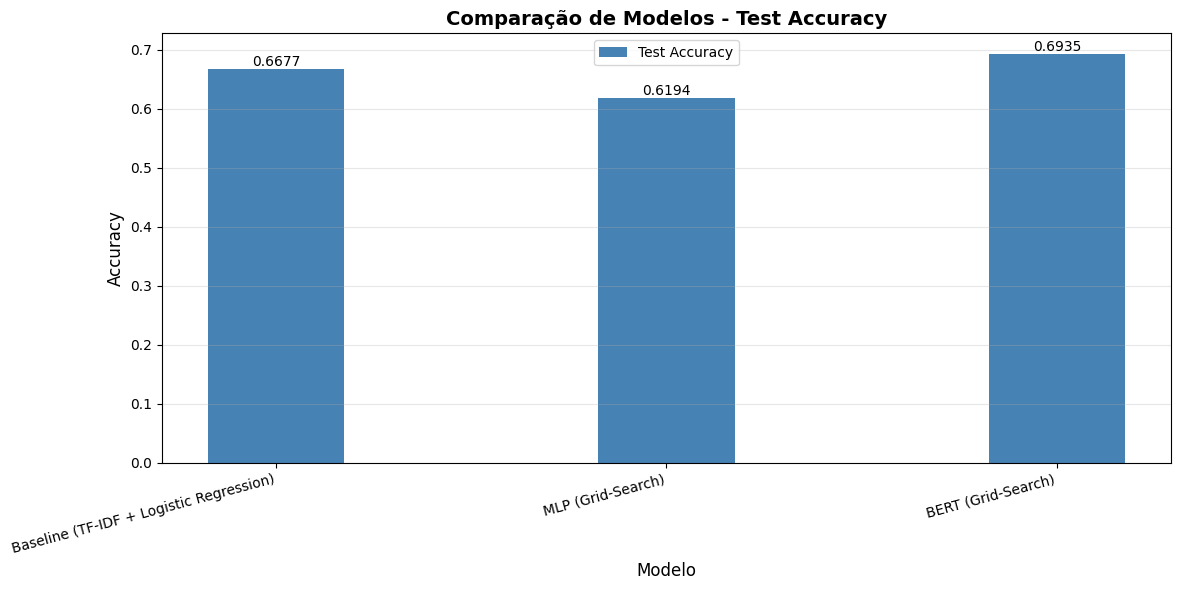


ANÁLISE
🏆 Melhor Modelo: BERT (Grid-Search)
   Test Accuracy: 0.6935

📈 Melhoria em relação ao Baseline:
   Baseline: 0.6677
   Melhor: 0.6935
   Melhoria: +3.86%

✅ COMPARAÇÃO CONCLUÍDA


In [ ]:

# Preparar dados para comparação
comparison_data = {
    'Modelo': [],
    'Test Accuracy': []
}

if 'cv_mean' in baseline_results:
    comparison_data['CV Accuracy (10 folds)'] = []

# Baseline
comparison_data['Modelo'].append('Baseline (TF-IDF + Logistic Regression)')
comparison_data['Test Accuracy'].append(baseline_results['test_score'])
if 'cv_mean' in baseline_results:
    comparison_data['CV Accuracy (10 folds)'].append(
        f"{baseline_results['cv_mean']:.4f} ± {baseline_results['cv_std']:.4f}"
    )

# MLP
try:
    if mlp_results and 'test_score' in mlp_results:
        comparison_data['Modelo'].append('MLP (Grid-Search)')
        comparison_data['Test Accuracy'].append(mlp_results['test_score'])
        if 'cv_mean' in baseline_results:
            comparison_data['CV Accuracy (10 folds)'].append(
                f"{mlp_results['best_cv_score']:.4f}"
            )
except NameError:
    print("MLP não foi executado ainda")

# BERT
try:
    if bert_final_results is not None and 'test_score' in bert_final_results:
        comparison_data['Modelo'].append('BERT (Grid-Search)')
        comparison_data['Test Accuracy'].append(bert_final_results['test_score'])
        if 'cv_mean' in baseline_results:
            comparison_data['CV Accuracy (10 folds)'].append('N/A')
except NameError:
    print("BERT não foi executado ainda")

# Criar DataFrame
comparison_df = pd.DataFrame(comparison_data)
print("TABELA COMPARATIVA:")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)


fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison_df))
width = 0.35

bars = ax.bar(x, comparison_df['Test Accuracy'], width, label='Test Accuracy', color='steelblue')

ax.set_xlabel('Modelo', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Comparação de Modelos - Test Accuracy', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Modelo'], rotation=15, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for i, (bar, acc) in enumerate(zip(bars, comparison_df['Test Accuracy'])):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.4f}',
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
comparison_path = os.path.join(figures_dir, 'model_comparison.png')
plt.savefig(comparison_path, dpi=300, bbox_inches='tight')
print(f"Figura salva: {comparison_path}")
plt.show()

print(f"\n{'='*80}")
print("ANÁLISE")
print(f"{'='*80}")

best_model_idx = comparison_df['Test Accuracy'].idxmax()
best_model = comparison_df.loc[best_model_idx, 'Modelo']
best_score = comparison_df.loc[best_model_idx, 'Test Accuracy']

print(f"🏆 Melhor Modelo: {best_model}")
print(f"   Test Accuracy: {best_score:.4f}")

print(f"Melhoria em relação ao Baseline:")
baseline_acc = comparison_df.loc[0, 'Test Accuracy']
improvement = ((best_score - baseline_acc) / baseline_acc) * 100
print(f"   Baseline: {baseline_acc:.4f}")
print(f"   Melhor: {best_score:.4f}")
print(f"   Melhoria: {improvement:+.2f}%")